In [1]:
from pathlib import Path
from dataclasses import dataclass
from scipy.stats import chi2
from datetime import datetime, timedelta
from typing import *

import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np


ROOT_DIR = Path(os.getcwd()).parent

In [2]:
@dataclass
class PumpEvent:
    ticker: str
    pump_time: str

    def __post_init__(self):
        self.pump_time = datetime.strptime(self.pump_time, "%Y-%m-%d %H:%M:%S")

pump = PumpEvent(
    ticker="AGIXBTC",
    pump_time="2022-08-14 16:00:05",
)

In [3]:
pump.pump_time.weekday()

6

In [4]:
def create_date_range(start: datetime, end: datetime) -> List[str]:
    """Creates a range of months and years between two dates"""
    start_year = start.year
    start_month = start.month
    end_year = end.year
    end_month = end.month

    date_range = []

    for year in range(start_year, end_year + 1):
        start_month_range = start_month if year == start_year else 1
        end_month_range = end_month if year == end_year else 12

        for month in range(start_month_range, end_month_range + 1):
            date_range.append(datetime(year=year, month=month, day=1))

    return date_range

In [5]:
def load_data(pump_event: PumpEvent, lookback_delta: timedelta) -> pl.DataFrame:
    rb = pump_event.pump_time
    lb = rb - lookback_delta

    ts_range = create_date_range(start=lb, end=rb)

    TICKER_DIR = os.path.join(ROOT_DIR, "data/trades", pump_event.ticker)
    df = pl.DataFrame()

    for date in ts_range:
        month, year = str(date.month).zfill(2), date.year
        slug = f"{pump_event.ticker}-{year}-{str(month).zfill(2)}.parquet"
        df_tmp = pl.read_parquet(os.path.join(TICKER_DIR, slug))

        df = df.vstack(df_tmp)

    return df

In [6]:
TWO_WEEKS_BEFORE = (
    (pl.col("time") >= pump.pump_time - timedelta(days=14)) &
    (pl.col("time") < pump.pump_time)
)

ONE_DAY_AHEAD = (
    (pl.col("time") >= pump.pump_time) &
    (pl.col("time") < pump.pump_time + timedelta(days=1))
)

In [7]:
df = load_data(pump_event=pump, lookback_delta=timedelta(days=60))
df = df.with_columns(time=pl.col("time").set_sorted())
df.head()

trade_id,price,qty,time,isBuyerMaker
i64,f64,f64,datetime[ns],bool
3032575,0.000002,220.0,2022-06-01 00:02:03.862,true
3032576,0.000002,3000.0,2022-06-01 00:03:17.177,false
3032577,0.000002,59.0,2022-06-01 00:03:38.722,false
3032578,0.000002,256.0,2022-06-01 00:04:06.108,false
3032579,0.000002,9339.0,2022-06-01 00:04:06.108,false


<h4>Group by trades by time - the same as rush trades defined in other papers</h4>

In [8]:
df_trades = (
    df.with_columns(
        qty_sign=(1 - 2 * pl.col("isBuyerMaker").cast(pl.Int8)) * pl.col("qty"),
    )
    .group_by("time", maintain_order=True)
    .agg(
        # Price aggregation
        price_first=pl.col("price").first(),
        price_last=pl.col("price").last(),
        price_mean=pl.col("price").mean(),
        price_min=pl.col("price").min(),
        price_max=pl.col("price").max(),
        # Check if the agg trade corresponds to one person
        isBuyerMaker_mean=pl.col("isBuyerMaker").mean(),
        # Qty aggregation
        qty_sign=pl.col("qty_sign").sum(),
        qty_abs=pl.col("qty").sum(),
        # Market slippage metrics (liquidity metrics)
        btc_lost_to_slippage=(
            # actual quote paid - what could have been achieved with limit order
            (pl.col("qty_sign") * pl.col("price")).sum() - (pl.col("qty_sign").sum() * pl.col("price").first())
        ),
        btc_quote_spent=((pl.col("qty_sign") * pl.col("price")).sum().abs()),
    )
    # Remove panic! cases when isBuyerMaker_mean \in (0, 1)
    # .filter(
    #     (pl.col("isBuyerMaker_mean") == 0) | (pl.col("isBuyerMaker_mean") == 1)
    # )
)

<p>We want to estimate price slippage from trade executed by market order</p>

$$\text{btc\_lost\_to\_slippage} = \sum_{i=1}^n{\text{qty\_sign}_i} \cdot \, P_i - \sum_{i=1}^n{\text{qty\_sign}_i} \cdot \, P_0$$

In [9]:
df_trades["isBuyerMaker_mean"].value_counts()

isBuyerMaker_mean,count
f64,u32
0.0,82657
0.8,1
0.992857,1
0.018868,1
0.987179,1
…,…
0.886364,1
0.137255,1
0.888889,1


<p>This could be interpreted as a measure of eagerness of market partipants to either go long or short</p>

$$\text{cum\_spread\_skew} = \frac{\text{Cumulative BTC lost by Buyers to slippage}}{\text{Cumulative BTC lost by Sellers to slippage}}$$

In [10]:
df_trades = df_trades.filter(
    (pl.col("time") >= pump.pump_time - timedelta(days=45))
    & (pl.col("time") <= pump.pump_time + timedelta(days=7))
)

In [11]:
df_trades = (
    df_trades
    .with_columns(
        is_long=pl.col("qty_sign") >= 0
    )
    .with_columns(
        btc_lost_by_buyers=pl.col("btc_lost_to_slippage") * pl.col("is_long"),
        btc_lost_by_sellers=pl.col("btc_lost_to_slippage") * ~pl.col("is_long")
    )
    .with_columns(
        cum_btc_lost_by_buyers=pl.col("btc_lost_by_buyers").cum_sum(),
        cum_btc_lost_by_sellers=pl.col("btc_lost_by_sellers").cum_sum()
    )
)

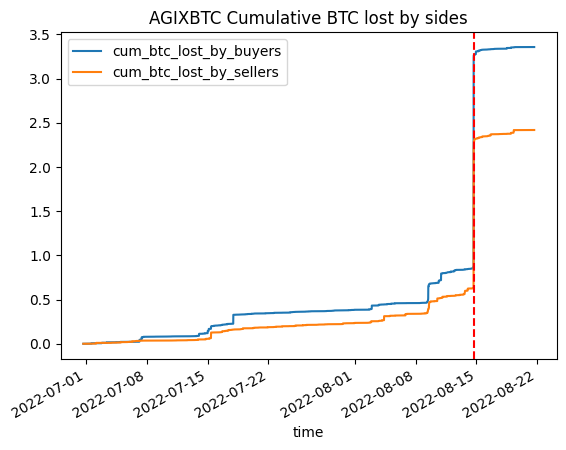

In [12]:
(
    df_trades
    .to_pandas()
    .plot(x="time", y=["cum_btc_lost_by_buyers", "cum_btc_lost_by_sellers"])
)

plt.title(f"{pump.ticker} Cumulative BTC lost by sides")
plt.axvline(x=pump.pump_time, color="red", linestyle="--")
plt.show()

In [13]:
offset = timedelta(
    minutes=pump.pump_time.minute,
    seconds=pump.pump_time.second
)

<h4>Rolling quantiles of volumes</h4>

In [14]:
long_quantile = (
    df_trades
    .filter(
        pl.col("is_long")
    )
    .group_by_dynamic(
        index_column="time", every="1h", period="7d", label="right", offset=offset
    )
    .agg(
        long_quantile_whale = pl.col("qty_abs").quantile(.999),
        long_quantile_99 = pl.col("qty_abs").quantile(.99),
        long_quantile_95 = pl.col("qty_abs").quantile(.95)
    )
)

df_quantiles = (
    df_trades
    .filter(
        ~pl.col("is_long")
    )
    .group_by_dynamic(
        index_column="time", every="1h", period="7d", label="right", offset=offset
    )
    .agg(
        short_quantile_whale = pl.col("qty_abs").quantile(0.999),
        short_quantile_99 = pl.col("qty_abs").quantile(.99),
        short_quantile_95 = pl.col("qty_abs").quantile(.95)
    )
    .join(
        long_quantile, how="left", on="time"
    )
)

In [15]:
df_trades = (
    df_trades
    .with_columns(
        time_quantile = (
            (pl.col("time") + timedelta(hours=1)).dt.truncate("1h") + offset
        ).cast(pl.Datetime(time_unit="ns"))
    )
    .join(
        df_quantiles, left_on="time_quantile", right_on="time", how="left"
    )
)

In [16]:
# add is_whale and is_99 indicators
df_trades = (
    df_trades
    .with_columns(
        # Whales
        is_long_whale = (
            (pl.col("qty_abs") >= pl.col("long_quantile_whale")) & pl.col("is_long")
        ),
        is_short_whale = (
            (pl.col("qty_abs") >= pl.col("short_quantile_whale")) & ~pl.col("is_long")
        ),
        # (0.99; 0.999)
        is_long_99 = (
            pl.col("qty_abs").is_between(pl.col("long_quantile_99"), pl.col("long_quantile_whale")) &
            pl.col("is_long")
        ),
        is_short_99 = (
            pl.col("qty_abs").is_between(pl.col("short_quantile_99"), pl.col("short_quantile_whale")) &
            ~pl.col("is_long")
        )
    )
    .with_columns(
        is_whale = pl.col("is_long_whale") | pl.col("is_short_whale"),
        is_99 = pl.col("is_long_99") | pl.col("is_short_99")
    )
)

<h4>Studying Slippage loss of whales in the run up to the pump</h4>

In [17]:
df_slippages = (
    df_trades
    .group_by_dynamic(
        index_column="time", every="1h", period="7d", label="right", offset=offset
    )
    .agg(
        # Whale slippage
        long_whale_slippage = (pl.col("btc_lost_to_slippage") * pl.col("is_long_whale")).sum(),
        short_whale_slippage = (pl.col("btc_lost_to_slippage") * pl.col("is_short_whale")).sum(),
        # 99 quantile slippage
        long_99_slippage = (pl.col("btc_lost_to_slippage") * pl.col("is_long_99")).sum(),
        short_99_slippage = (pl.col("btc_lost_to_slippage") * pl.col("is_short_99")).sum(),
    )
    .with_columns(
        net_whale_slippage = pl.col("long_whale_slippage") - pl.col("short_whale_slippage"),
        net_99_slippage = pl.col("long_99_slippage") - pl.col("short_99_slippage")
    )
    .select(
        "time", "net_whale_slippage", "net_99_slippage"
    )
)

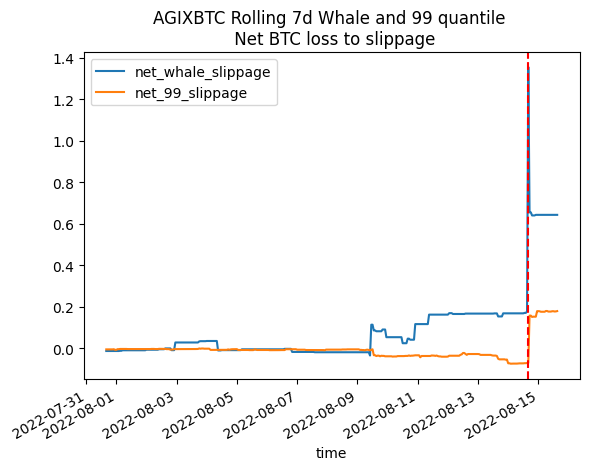

In [18]:
(
    df_slippages
    .filter(
        TWO_WEEKS_BEFORE | ONE_DAY_AHEAD
    )
    .to_pandas()
    .plot(x="time", y=["net_whale_slippage", "net_99_slippage"])
)

plt.title(f"{pump.ticker} Rolling 7d Whale and 99 quantile \n Net BTC loss to slippage")
plt.axvline(x=pump.pump_time, color="red", linestyle="--")
plt.show()

$$\text{Imbalance\_ratio} = \frac{\text{Net Whale Position}}{\text{Overall whale trading volume}}$$

<h4>Whale imbalance ratio</h4>

In [19]:
df_imbalances = (
    df_trades
    .group_by_dynamic(
        index_column="time", every="1h", period="7d", label="right", offset=offset
    )
    .agg(
        # Whale quantities
        whale_net_position = (pl.col("qty_sign") * pl.col("is_whale")).sum(),
        whale_overall_vol = (pl.col("qty_abs") * pl.col("is_whale")).sum(),
        # 99 quantile
        quan_99_net_position = (pl.col("qty_sign") * pl.col("is_99")).sum(),
        quan_99_overall_vol = (pl.col("qty_abs") * pl.col("is_99")).sum()
    )
    .with_columns(
        whale_imbalance_ratio = pl.col("whale_net_position") / pl.col("whale_overall_vol"),
        quan_99_imbalance_ratio = pl.col("quan_99_net_position") / pl.col("quan_99_overall_vol"),
    )
    .select(
        "time", "whale_imbalance_ratio", "quan_99_imbalance_ratio"
    )
)

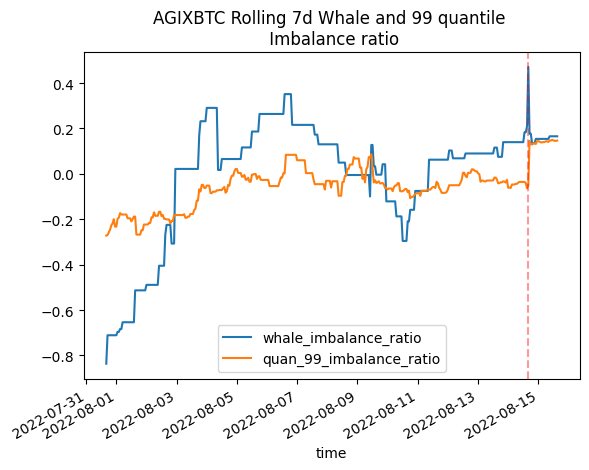

In [20]:
(
    df_imbalances
    .filter(
        TWO_WEEKS_BEFORE | ONE_DAY_AHEAD
    )
    .to_pandas()
    .plot(x="time", y=["whale_imbalance_ratio", "quan_99_imbalance_ratio"])
)

plt.title(f"{pump.ticker} Rolling 7d Whale and 99 quantile \n Imbalance ratio")
plt.axvline(x=pump.pump_time, color="red", linestyle="--", alpha=0.4)
plt.show()

<h4>Studying number of trades and their timing</h4>

In [21]:
df_num_trades = (
    df_trades
    .group_by_dynamic(
        index_column="time", every="1h", period="7d", label="right", offset=offset
    )
    .agg(
        num_trades_long_whale = pl.col("is_long_whale").sum(),
        num_trades_short_whale = pl.col("is_short_whale").sum(),
        num_trades_long_99 = pl.col("is_long_99").sum(),
        num_trades_short_99 = pl.col("is_short_99").sum()
    )
    .with_columns(
        long_whale_99_num_trades_ratio = (
            pl.col("num_trades_long_whale") / pl.col("num_trades_long_99")
        ),
        short_whale_99_num_trades_ratio = (
            pl.col("num_trades_short_whale") / pl.col("num_trades_short_99")
        )
    )
    .select(
        "time", "long_whale_99_num_trades_ratio", "short_whale_99_num_trades_ratio"
    )
)

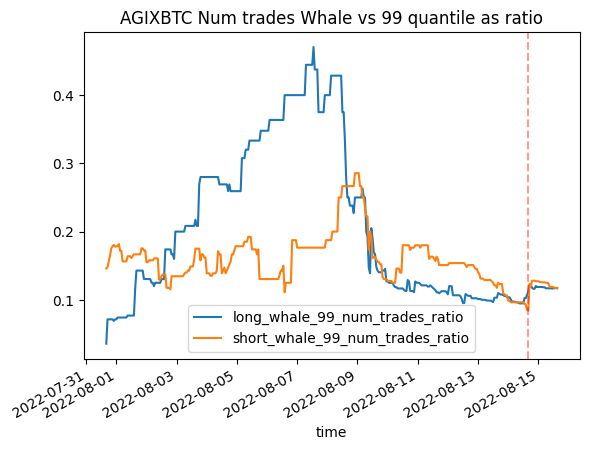

In [22]:
(
    df_num_trades
    .filter(
        TWO_WEEKS_BEFORE | ONE_DAY_AHEAD
    )
    .to_pandas()
    .plot(
        x="time", 
        y=["long_whale_99_num_trades_ratio", "short_whale_99_num_trades_ratio"]
    )
)

plt.title(f"{pump.ticker} Num trades Whale vs 99 quantile as ratio")
plt.axvline(x=pump.pump_time, color="red", linestyle="--", alpha=0.4)
plt.show()

<h4>Klines plot at pump time</h4>

In [23]:
df_klines = (
    df_trades
    .group_by_dynamic(
        index_column="time", every="1s"
    )
    .agg(
        open = pl.col("price_first").first(),
        close = pl.col("price_last").last(),
        volume = pl.col("qty_abs").sum(),
        high = pl.col("price_max").max(),
        low = pl.col("price_min").min()
    )
    .filter(
        (pl.col("time") >= pump.pump_time - timedelta(seconds=60)) &
        (pl.col("time") <= pump.pump_time + timedelta(seconds=30))
    )
    .to_pandas()
)

df_klines.index = df_klines["time"]

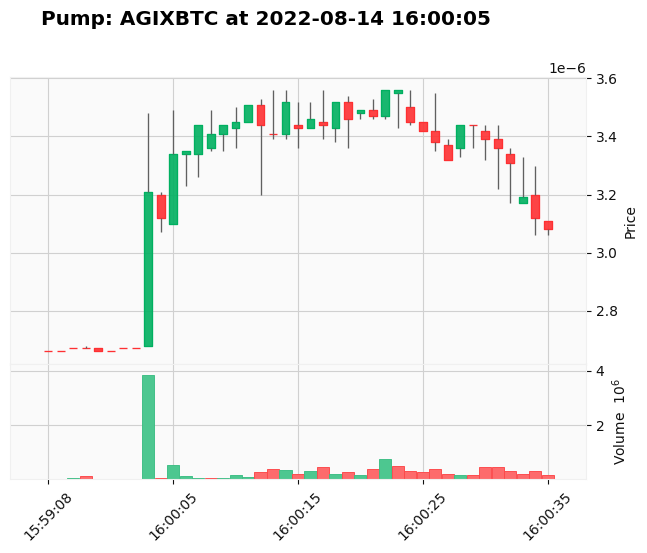

In [24]:
import mplfinance as mpl

mpl.plot(
    data=df_klines,
    title=f"Pump: {pump.ticker} at {pump.pump_time}",
    type="candle",
    style="yahoo",
    datetime_format="%H:%M:%S",
    volume=True
)

plt.show()

<h4>Attempting to capture periodic nature of big volume buys</h4>

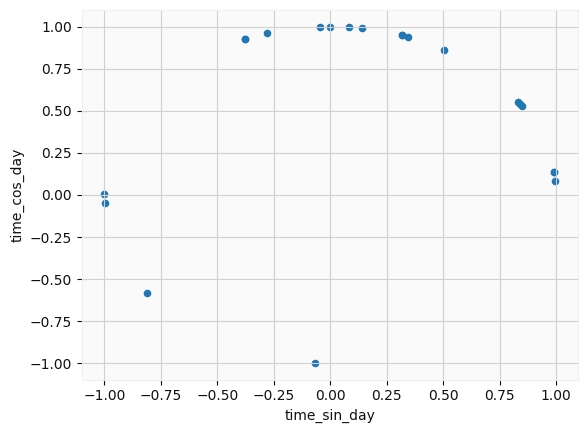

In [25]:
TOTAL_SECONDS_DAY = 60*60*24

(
    df_trades
    .filter(
        pl.col("is_long_whale") & TWO_WEEKS_BEFORE
    )
    .with_columns(
        seconds_to_pump_mod_day = (
            (pump.pump_time - pl.col("time")).dt.total_seconds() % TOTAL_SECONDS_DAY
        )
    )
    .with_columns(
        time_sin_day = np.sin(2 * np.pi * pl.col("seconds_to_pump_mod_day") / TOTAL_SECONDS_DAY),
        time_cos_day = np.cos(2 * np.pi * pl.col("seconds_to_pump_mod_day") / TOTAL_SECONDS_DAY),
    )
    .to_pandas()
    .plot.scatter(x="time_sin_day", y="time_cos_day")
)
plt.show()

<h4>Volume and BTC loss to slippage by weekday</h4>

In [38]:
df_trades = (
    df_trades
    .with_columns(
        weekday = pl.col("time").dt.weekday()
    )
)

weekday_dummies = df_trades["weekday"].to_dummies()
weekday_cols = weekday_dummies.columns

In [39]:
df_weekday = (
    df_trades
    .with_columns_seq(
        weekday_dummies
    )
    .group_by_dynamic(
        index_column="time", every="1h", period="7d", label="right", offset=offset
    )
    .agg([
        (pl.col("qty_abs") * pl.col("is_long_whale") * pl.col(col)).sum().alias(col)
        for col in weekday_cols
    ])
    .with_columns_seq([
        (pl.col(col) / pl.sum_horizontal(weekday_cols)).abs()
        for col in weekday_cols
    ])
)

df_weekday.head(1)

time,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weekday_7
datetime[ns],f64,f64,f64,f64,f64,f64,f64
2022-07-07 16:00:05,NaN,NaN,NaN,NaN,NaN,NaN,NaN


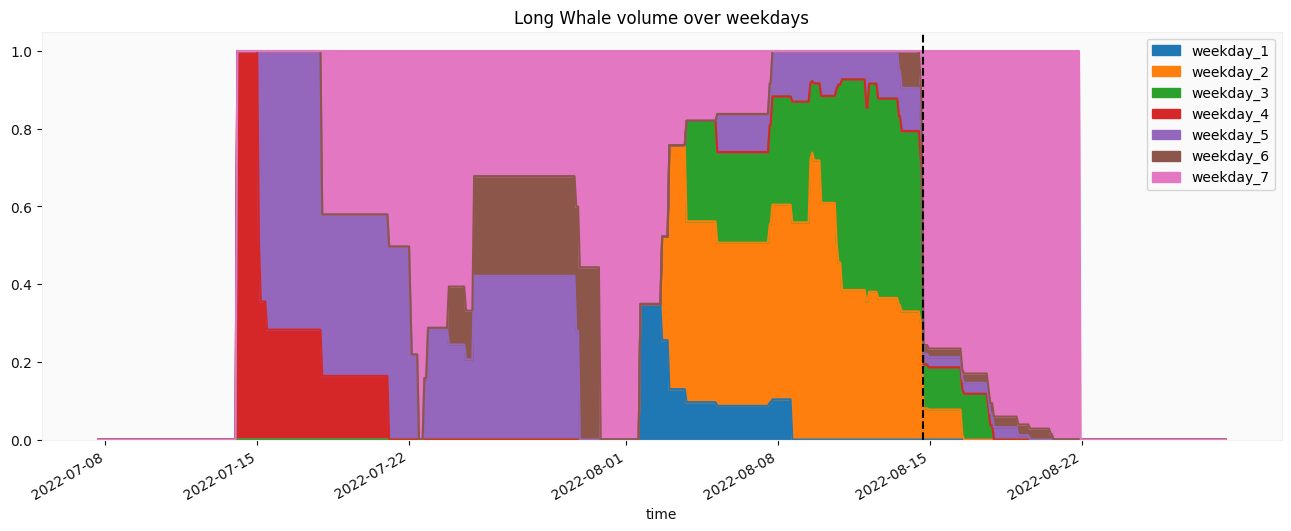

In [40]:
(
    df_weekday
    .to_pandas()
    .plot.area(x="time", y=weekday_cols, figsize=(16, 6))
)

plt.grid()
plt.title("Long Whale volume over weekdays")
plt.axvline(x=pump.pump_time, color="black", linestyle="--")
plt.show()

<h4>Benfard's Law</h4>

In [41]:
df_trades = (
    df_trades
    .with_columns(
        first_digit = pl.col("qty_abs").cast(str).str.slice(0, 1).cast(pl.Int8)
    )
)

In [42]:
digit_dummies = df_trades["first_digit"].to_dummies()
digit_cols = digit_dummies.columns[1:] 

In [43]:
# logarithmic distribution Benford's law
expected_freq = pl.Series([np.log(i + 1) - np.log(i) for i in range(1, 10)])

In [44]:
from scipy.stats import chi2

In [45]:
df_benfard = (
    df_trades
    .with_columns_seq(
        digit_dummies
    )
    .filter(
        pl.col("is_long_whale")
    )
    .group_by_dynamic(
        index_column="time", every="1h", period="7d", label="right", offset=offset
    )
    .agg([
        pl.col(col).sum()
        for col in digit_cols
    ])
    .with_columns_seq([
        (pl.col(col) / pl.sum_horizontal(digit_cols) - expected_freq[i])**2 / expected_freq[i]
        for i, col in enumerate(digit_cols)
    ])
    .with_columns(
        chi2_stat = pl.sum_horizontal(digit_cols)
    )
    .select("time", "chi2_stat")
)

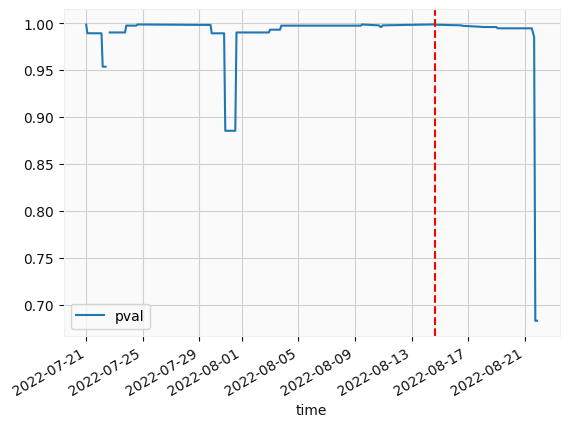

In [46]:
pval = 1 - chi2.cdf(x=df_benfard["chi2_stat"], df=8)

(
    df_benfard
    .with_columns(
        pval = pval
    )
    .to_pandas()
    .plot(x="time", y="pval")
)

plt.axvline(x=pump.pump_time, color="red", linestyle="--")
plt.show()

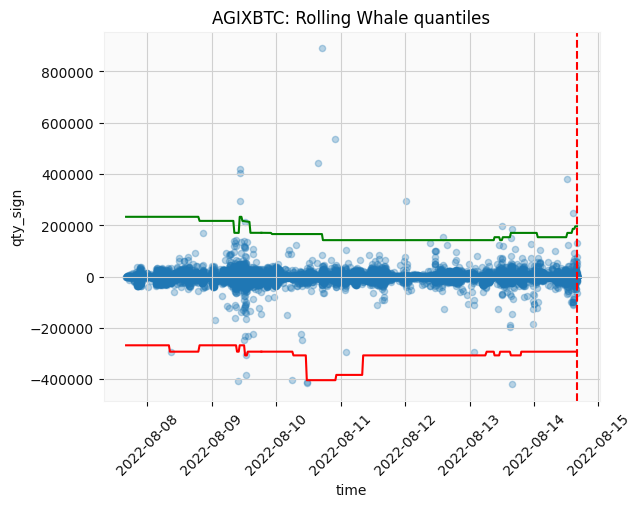

In [47]:
df_plot = df_trades.filter(
    (pl.col("time") > pump.pump_time - timedelta(hours=24*7)) &
    (pl.col("time") < pump.pump_time - timedelta(seconds=10))
)

(
    df_plot
    .to_pandas()
    .plot.scatter(x="time", y="qty_sign", alpha=.3)
)

plt.plot(df_plot["time"], df_plot["long_quantile_whale"], color="green")
plt.plot(df_plot["time"], -df_plot["short_quantile_whale"], color="red")

plt.title(f"{pump.ticker}: Rolling Whale quantiles")
plt.axvline(x=pump.pump_time, color="red", linestyle="--")
plt.xticks(rotation=45)
plt.show()

<h4>Output features to dataframe</h4>

In [51]:
df_slippages.head(2)

time,net_whale_slippage,net_99_slippage
datetime[ns],f64,f64
2022-07-07 16:00:05,0.0,0.0
2022-07-07 17:00:05,0.0,0.0


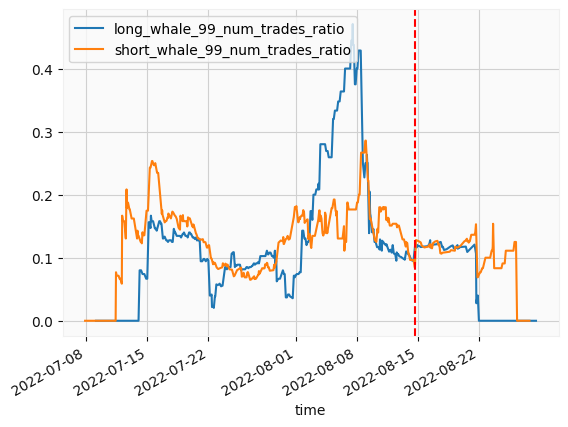

In [60]:
df_num_trades.to_pandas().plot(
    x="time", y=["long_whale_99_num_trades_ratio", "short_whale_99_num_trades_ratio"]
)

plt.axvline(
    x=pump.pump_time, color="red", linestyle="--"
)
plt.show()

In [62]:
df_num_trades.head(2)

time,long_whale_99_num_trades_ratio,short_whale_99_num_trades_ratio
datetime[ns],f64,f64
2022-07-07 16:00:05,NaN,NaN
2022-07-07 17:00:05,NaN,NaN


In [63]:
df_slippages.head(2)

time,net_whale_slippage,net_99_slippage
datetime[ns],f64,f64
2022-07-07 16:00:05,0.0,0.0
2022-07-07 17:00:05,0.0,0.0


In [83]:
# merge all data into single features dataframe
df_features = (
    df_slippages
    .join(
        df_num_trades, on="time", how="left"
    )
    .join(
        df_imbalances, on="time", how="left"
    )
    .filter(
        (pl.col("time") >= pump.pump_time - timedelta(days=7)) & # 7 days before the pump
        (pl.col("time") <= pump.pump_time - timedelta(hours=1)) # add all features 1 hour prior to the pump
    )
    .to_pandas()
    .drop(
        columns=["time"]
    )
)

df_features.head(1)

,net_whale_slippage,net_99_slippage,long_whale_99_num_trades_ratio,short_whale_99_num_trades_ratio,whale_imbalance_ratio,quan_99_imbalance_ratio
0,-0.018766,-0.008339,0.4375,0.176471,0.172866,-0.045306


In [84]:
# flatten the matrix into the vector
df_features.index = [f"{i}_H" for i in range(1, 24 * 7 + 1)]
df_features = df_features.unstack().to_frame().sort_index(level=1).T
df_features.columns = df_features.columns.map("_".join)

In [85]:
df_features

,long_whale_99_num_trades_ratio_100_H,net_99_slippage_100_H,net_whale_slippage_100_H,quan_99_imbalance_ratio_100_H,short_whale_99_num_trades_ratio_100_H,whale_imbalance_ratio_100_H,long_whale_99_num_trades_ratio_101_H,net_99_slippage_101_H,net_whale_slippage_101_H,quan_99_imbalance_ratio_101_H,...,net_whale_slippage_99_H,quan_99_imbalance_ratio_99_H,short_whale_99_num_trades_ratio_99_H,whale_imbalance_ratio_99_H,long_whale_99_num_trades_ratio_9_H,net_99_slippage_9_H,net_whale_slippage_9_H,quan_99_imbalance_ratio_9_H,short_whale_99_num_trades_ratio_9_H,whale_imbalance_ratio_9_H
0,0.112676,-0.040236,0.162335,-0.083483,0.150943,0.062574,0.112676,-0.040236,0.162335,-0.083483,...,0.162335,-0.070015,0.150943,0.062574,0.4,-0.006195,-0.018766,-0.0306,0.1875,0.130197
